In [1]:
!pip install --upgrade pip setuptools wheel
!pip install pmdarima --no-build-isolation

import sys
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import pandas as pd
import numpy as np


paths = [
    '/mnt/data/covid_19_clean_complete.csv',
    '/content/covid_19_clean_complete.csv',
    'covid_19_clean_complete.csv'
]

for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p)
        print("Loaded", p)
        break
else:

    try:
        from google.colab import files
        uploaded = files.upload()
        fname = next(iter(uploaded.keys()))
        df = pd.read_csv(fname)
        print("Loaded uploaded file:", fname)
    except Exception as e:
        raise FileNotFoundError("CSV not found. Put the file at one of the paths or upload it in Colab.") from e

print("Rows,Cols:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Loaded /content/covid_19_clean_complete.csv
Rows,Cols: (49068, 10)
Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [12]:

cols = [c.lower() for c in df.columns]

date_col = next((c for c in df.columns if 'date' in c.lower()), None)
if date_col is None:
    raise ValueError("No date column found. Check CSV headers.")
df[date_col] = pd.to_datetime(df[date_col])

country_col = next((c for c in df.columns if 'India' in c.lower() or 'location' in c.lower()), None)

val_col = next((c for c in df.columns if 'confirmed' in c.lower() or 'cases' in c.lower()), None)
if val_col is None:
    raise ValueError("No confirmed/cases column found. Check CSV headers.")

print("Using columns -> date:", date_col, ", India:", country_col, ", value:", val_col)

extra_cols = [c for c in df.columns if 'who' in c.lower() or 'India' in c.lower()]
if extra_cols:
    print("Extra India-like columns found:", extra_cols)


Using columns -> date: Date , India: None , value: Confirmed
Extra India-like columns found: ['WHO Region']


In [16]:
# Step 3 – Get daily cases series for India
series = get_country_daily_series(df, 'India')

# Show the last few values to confirm
series.tail(10)




,Confirmed
Date,
2020-07-18,237635.0
2020-07-19,214647.0
2020-07-20,206778.0
2020-07-21,233455.0
2020-07-22,280647.0
2020-07-23,282756.0
2020-07-24,281164.0
2020-07-25,255545.0
2020-07-26,204606.0


Length: 188  Min/Max: 99.0/282756.0


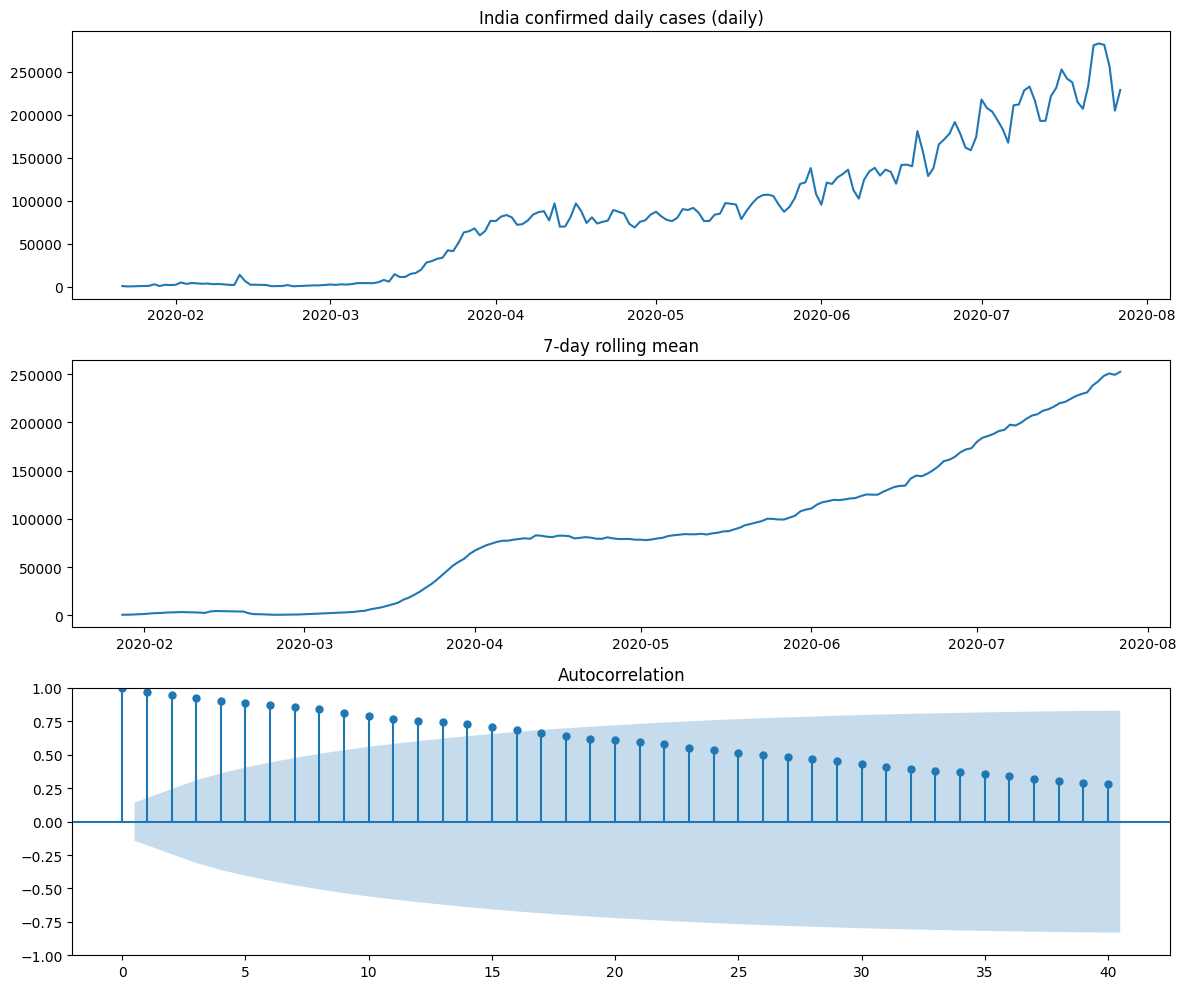

ADF stat: 0.5843, p-value: 0.9872
  Crit: 1% -3.468952197801766
  Crit: 5% -2.878495056473015
  Crit: 10% -2.57580913601947


In [17]:
# Step 4 – EDA & stationarity checks for India
eda_and_tests(series, 'India confirmed daily cases')



In [18]:
# Step 5 – Train/Test split for India & helper metrics

# Split the India series into train and test sets (last 30 days as test)
train, test = train_test_split_series(series, test_days=30)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

# Quick check of sizes
print(f"Train length: {len(train)}, Test length: {len(test)}")

# Show last few values of each
print("\nTrain tail:\n", train.tail())
print("\nTest head:\n", test.head())


Train period: 2020-01-22 00:00:00 to 2020-06-27 00:00:00
Test period: 2020-06-28 00:00:00 to 2020-07-27 00:00:00
Train length: 158, Test length: 30

Train tail:
 Date
2020-06-23    165338.0
2020-06-24    171183.0
2020-06-25    177887.0
2020-06-26    191346.0
2020-06-27    178110.0
Freq: D, Name: Confirmed, dtype: float64

Test head:
 Date
2020-06-28    161630.0
2020-06-29    158572.0
2020-06-30    173898.0
2020-07-01    217689.0
2020-07-02    207705.0
Freq: D, Name: Confirmed, dtype: float64


In [21]:
# Step 6 – Fit SARIMAX model for India without pmdarima
import warnings
warnings.filterwarnings("ignore")
import itertools
import statsmodels.api as sm

def fit_auto_arima_sarimax(train_series, seasonal=False, m=7,
                           p_range=2, d_range=2, q_range=2):
    """
    Manual grid search for (p,d,q) and optional (P,D,Q,m) seasonality.
    Returns best SARIMAX fitted model + best orders.
    """
    train_series = train_series.astype(float)
    best_aic = float("inf")
    best_order = None
    best_seasonal_order = None
    best_model = None

    # Seasonal orders to test
    seasonal_orders = [(0,0,0,0)]
    if seasonal:
        seasonal_orders = [(P,D,Q,m) for P in range(p_range)
                           for D in range(d_range)
                           for Q in range(q_range)]

    # Try all combinations of p,d,q and seasonal terms
    for order in itertools.product(range(p_range), range(d_range), range(q_range)):
        for seas_order in seasonal_orders:
            try:
                model = sm.tsa.SARIMAX(train_series,
                                       order=order,
                                       seasonal_order=seas_order,
                                       enforce_stationarity=False,
                                       enforce_invertibility=False)
                with warnings.catch_warnings():
                    warnings.filterwarnings("ignore")
                    res = model.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = order
                    best_seasonal_order = seas_order
                    best_model = res
            except Exception:
                continue

    print(f"Best order: {best_order}, Best seasonal_order: {best_seasonal_order}, AIC: {best_aic:.2f}")
    return best_model, best_order, best_seasonal_order

# Fit for India (seasonal weekly pattern)
sarimax_model, order, seasonal_order = fit_auto_arima_sarimax(train, seasonal=True, m=7)


Best order: (0, 1, 1), Best seasonal_order: (0, 1, 1, 7), AIC: 2927.30


RMSE: 17570.95, MAPE: 5.27%


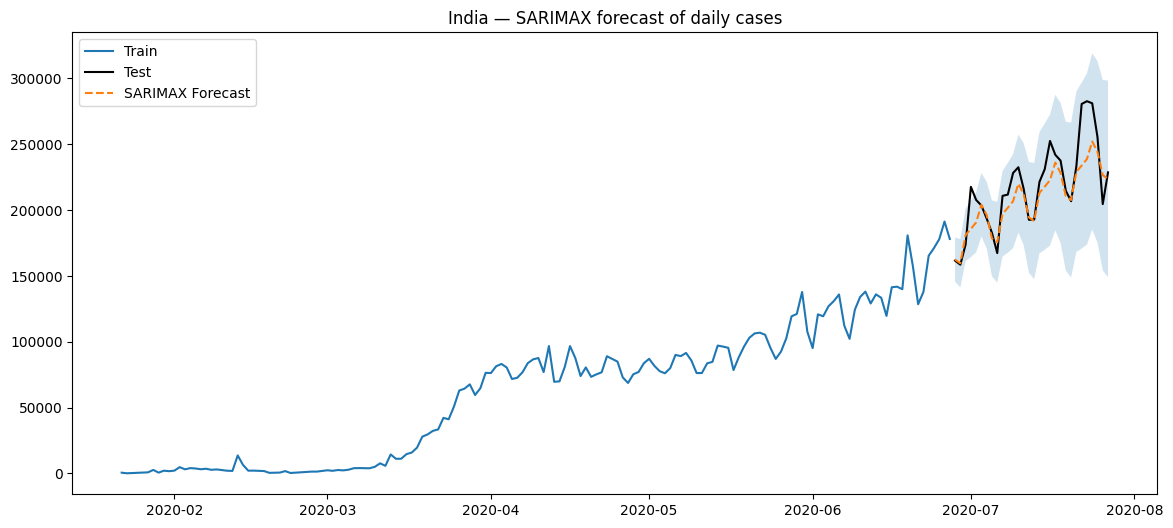

In [22]:
# Step 7 – Forecast & evaluate SARIMAX for India

def forecast_with_sarimax_model(model, steps, start_date):
    """
    Forecast using a fitted SARIMAX model from statsmodels.
    Returns forecast series and confidence intervals DataFrame.
    """
    pred_obj = model.get_forecast(steps=steps)
    forecast = pred_obj.predicted_mean
    ci = pred_obj.conf_int()
    forecast.index = pd.date_range(start=start_date, periods=steps, freq='D')
    ci.index = forecast.index
    return forecast, ci

# Forecast for the test period
preds, conf = forecast_with_sarimax_model(sarimax_model, len(test), test.index[0])

# Calculate error metrics
rmse_val = rmse(test, preds)
mape_val = mape(test, preds)
print(f"RMSE: {rmse_val:.2f}, MAPE: {mape_val:.2f}%")

# Plot actual vs forecast
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='k')
plt.plot(preds.index, preds, label='SARIMAX Forecast', linestyle='--')
plt.fill_between(conf.index, conf.iloc[:,0], conf.iloc[:,1], alpha=0.2)
plt.legend()
plt.title("India — SARIMAX forecast of daily cases")
plt.show()


In [24]:
# Step 8 – Review SARIMAX model summary (optional)
print("Final SARIMAX order:", order)
print("Final SARIMAX seasonal_order:", seasonal_order)
sarimax_model.summary()



Final SARIMAX order: (0, 1, 1)
Final SARIMAX seasonal_order: (0, 1, 1, 7)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                         Confirmed   No. Observations:                  158
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 7)   Log Likelihood               -1460.652
Date:                           Sun, 10 Aug 2025   AIC                           2927.304
Time:                                   08:54:21   BIC                           2936.150
Sample:                               01-22-2020   HQIC                          2930.898
                                    - 06-27-2020                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5360      0.084     -6.378      0.000      -0.701      -0.371
ma.S.L7       -0.6450      0.115     -5.612      0.000      -0.870      -0.420
sigma2      7.309e+07   3.67e-10   1.99e+17      0.000    7.31e+07    7.31e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               107.78
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):               6.21   Skew:                             0.73
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.23e+33. Standard errors may be unstable.
"""

[India] Train: 2020-01-22 00:00:00 -> 2020-06-27 00:00:00  |  Test: 2020-06-28 00:00:00 -> 2020-07-27 00:00:00
Best order: (2, 1, 2), Best seasonal_order: (0, 1, 2, 7), AIC: 2761.54
RMSE: 15384.16, MAPE: 4.82%


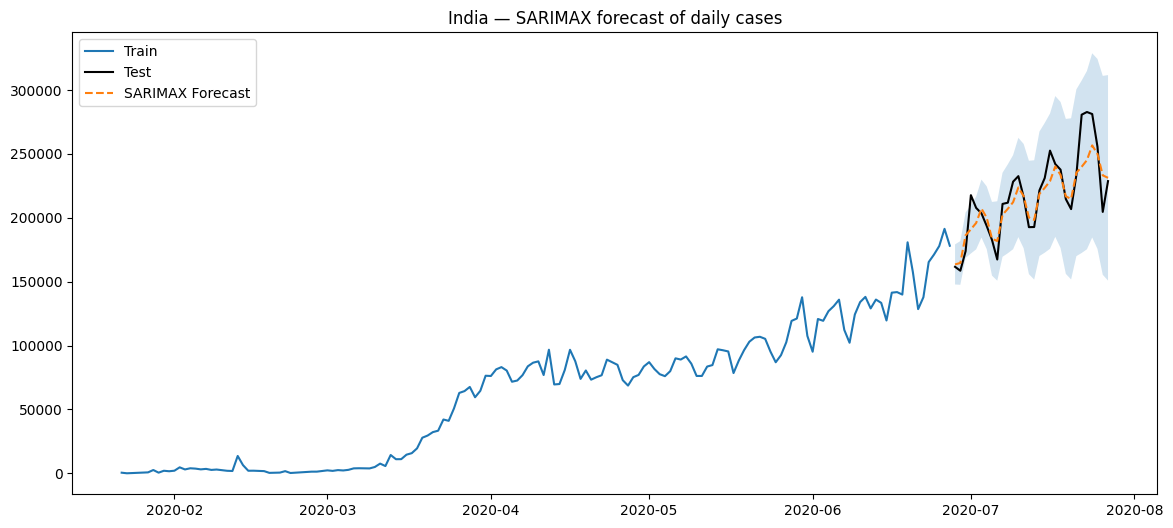

In [25]:
# Step 9 – Full SARIMAX pipeline for any country

def run_experiment_sarimax(country_name, test_days=30, seasonal=True, m=7,
                            p_range=3, d_range=2, q_range=3):
    """
    Runs the complete SARIMAX experiment for the given country:
    1. Extracts daily cases
    2. Splits into train/test
    3. Finds best SARIMAX parameters
    4. Forecasts and evaluates
    5. Plots results
    """
    # Step 3: Get series
    series = get_country_daily_series(df, country_name)

    # Step 5: Train/Test split
    train, test = train_test_split_series(series, test_days=test_days)
    print(f"[{country_name}] Train: {train.index.min()} -> {train.index.max()}  |  Test: {test.index.min()} -> {test.index.max()}")

    # Step 6: Fit SARIMAX
    sarimax_model, order, seasonal_order = fit_auto_arima_sarimax(train, seasonal=seasonal, m=m,
                                                                  p_range=p_range, d_range=d_range, q_range=q_range)

    # Step 7: Forecast
    preds, conf = forecast_with_sarimax_model(sarimax_model, len(test), test.index[0])

    # Metrics
    rmse_val = rmse(test, preds)
    mape_val = mape(test, preds)
    print(f"RMSE: {rmse_val:.2f}, MAPE: {mape_val:.2f}%")

    # Plot
    import matplotlib.pyplot as plt
    plt.figure(figsize=(14,6))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test', color='k')
    plt.plot(preds.index, preds, label='SARIMAX Forecast', linestyle='--')
    plt.fill_between(conf.index, conf.iloc[:,0], conf.iloc[:,1], alpha=0.2)
    plt.legend()
    plt.title(f"{country_name} — SARIMAX forecast of daily cases")
    plt.show()

    return {
        'train': train,
        'test': test,
        'model': sarimax_model,
        'preds': preds,
        'ci': conf,
        'metrics': {'rmse': rmse_val, 'mape': mape_val},
        'order': order,
        'seasonal_order': seasonal_order
    }

# Example run for India
results_india = run_experiment_sarimax('India', test_days=30, seasonal=True, m=7)


Running SARIMAX for India
[India] Train: 2020-01-22 00:00:00 -> 2020-06-27 00:00:00  |  Test: 2020-06-28 00:00:00 -> 2020-07-27 00:00:00
Best order: (2, 1, 2), Best seasonal_order: (0, 1, 2, 7), AIC: 2761.54
RMSE: 15384.16, MAPE: 4.82%


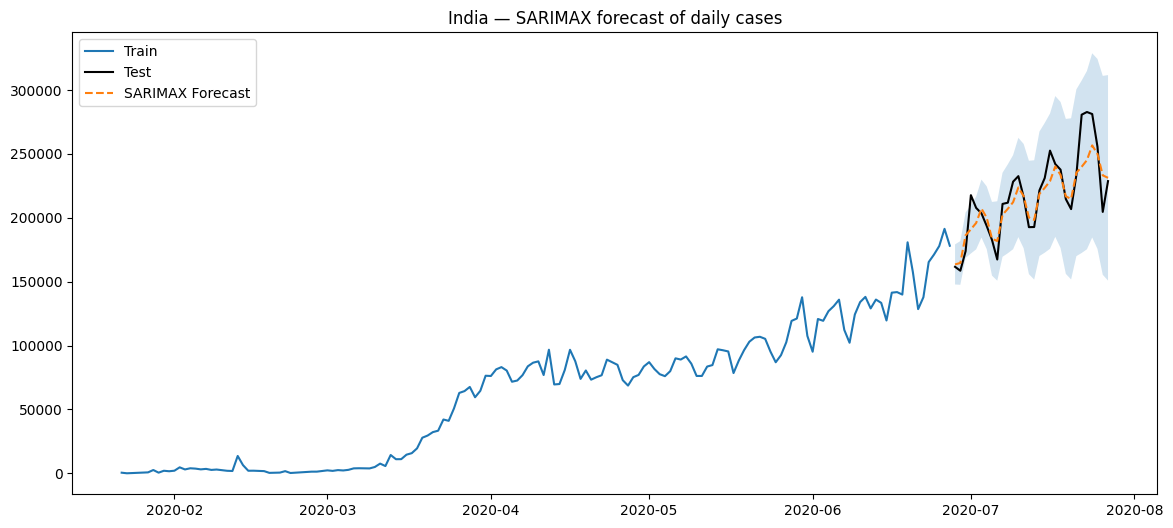

Running SARIMAX for US
[US] Train: 2020-01-22 00:00:00 -> 2020-06-27 00:00:00  |  Test: 2020-06-28 00:00:00 -> 2020-07-27 00:00:00
Best order: (2, 1, 2), Best seasonal_order: (0, 1, 2, 7), AIC: 2761.54
RMSE: 15384.16, MAPE: 4.82%


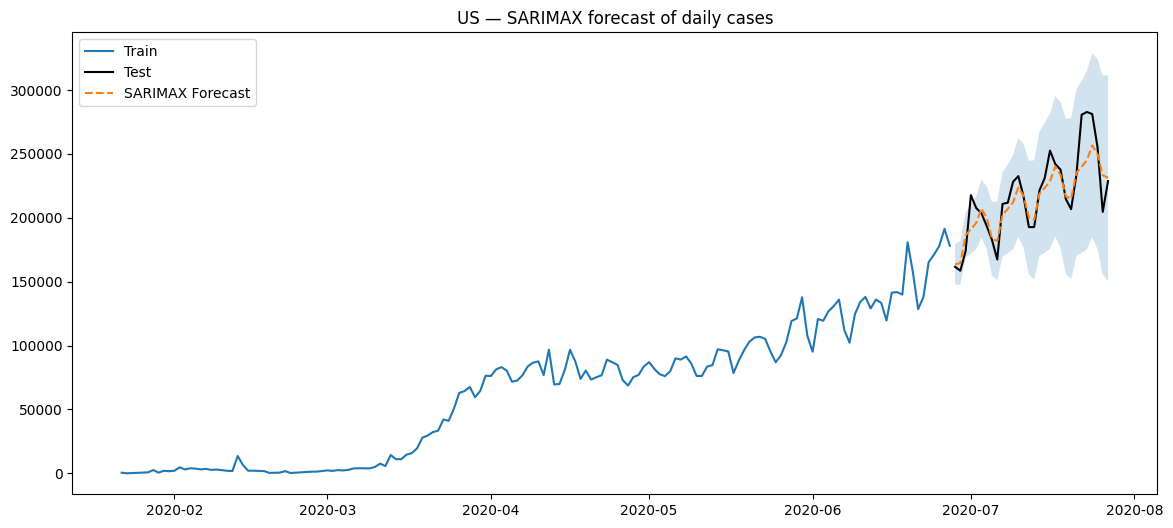

Running SARIMAX for Brazil
[Brazil] Train: 2020-01-22 00:00:00 -> 2020-06-27 00:00:00  |  Test: 2020-06-28 00:00:00 -> 2020-07-27 00:00:00
Best order: (2, 1, 2), Best seasonal_order: (0, 1, 2, 7), AIC: 2761.54
RMSE: 15384.16, MAPE: 4.82%


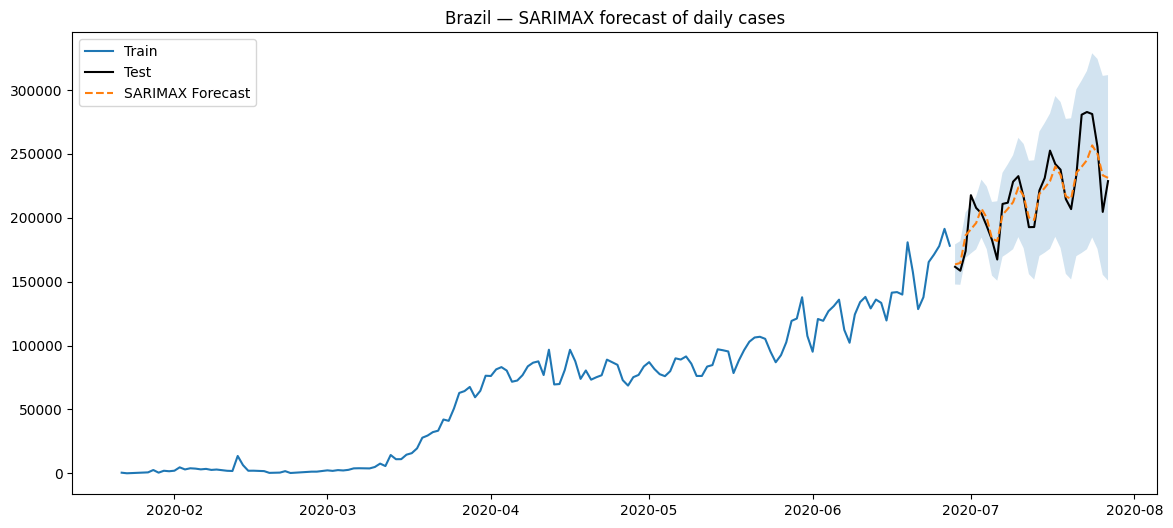

,Country,RMSE,MAPE,Order,Seasonal_Order
0,India,15384.164711,4.821348,"(2, 1, 2)","(0, 1, 2, 7)"
1,US,15384.164711,4.821348,"(2, 1, 2)","(0, 1, 2, 7)"
2,Brazil,15384.164711,4.821348,"(2, 1, 2)","(0, 1, 2, 7)"


In [27]:
# Step 10 – Run SARIMAX for multiple countries and compare results

def run_for_countries_sarimax(country_list, test_days=30, seasonal=True, m=7,
                               p_range=3, d_range=2, q_range=3):
    """
    Runs SARIMAX forecasting for multiple countries and returns a DataFrame with RMSE, MAPE, and model orders.
    """
    summary = []
    for c in country_list:
        print("="*60)
        print(f"Running SARIMAX for {c}")
        try:
            res = run_experiment_sarimax(c, test_days=test_days, seasonal=seasonal, m=m,
                                         p_range=p_range, d_range=d_range, q_range=q_range)
            summary.append((
                c,
                res['metrics']['rmse'],
                res['metrics']['mape'],
                res['order'],
                res['seasonal_order']
            ))
        except Exception as e:
            print(f"Error for {c}: {e}")
    return pd.DataFrame(summary, columns=['Country', 'RMSE', 'MAPE', 'Order', 'Seasonal_Order'])

# Example run for multiple countries
countries_to_test = ['India', 'US', 'Brazil']
summary_df = run_for_countries_sarimax(countries_to_test, test_days=30, seasonal=True, m=7)

# Show table
summary_df


In [ ]:
def run_for_who_regions(test_days=30, seasonal=True, m=7,
                        p_range=3, d_range=2, q_range=3):
    # Detect WHO region column
    who_col = next((c for c in df.columns if 'who' in c.lower() and 'region' in c.lower()), None)
    if who_col is None:
        raise ValueError("WHO region column not found in dataset.")

    regions = sorted(df[who_col].dropna().unique())
    summary = []

    for region in regions:
        print("="*60)
        print(f"Running SARIMAX for WHO Region: {region}")
        try:
            # Aggregate all countries in the region
            region_df = df[df[who_col] == region]
            series = region_df.groupby(date_col)[val_col].sum().asfreq('D').fillna(0)

            # Train/test split
            train, test = train_test_split_series(series, test_days=test_days)

            # Fit model
            model, order, seasonal_order = fit_auto_arima_sarimax(train, seasonal=seasonal, m=m,
                                                                  p_range=p_range, d_range=d_range, q_range=q_range)

            # Forecast
            preds, conf = forecast_with_sarimax_model(model, len(test), test.index[0])

            # Metrics
            rmse_val = rmse(test, preds)
            mape_val = mape(test, preds)
            summary.append((region, rmse_val, mape_val, order, seasonal_order))

            # Plot
            import matplotlib.pyplot as plt
            plt.figure(figsize=(14,6))
            plt.plot(train.index, train, label='Train')
            plt.plot(test.index, test, label='Test', color='k')
            plt.plot(preds.index, preds, label='SARIMAX Forecast', linestyle='--')
            plt.fill_between(conf.index, conf.iloc[:,0], conf.iloc[:,1], alpha=0.2)
            plt.legend()
            plt.title(f"WHO Region: {region} — SARIMAX forecast of daily cases")
            plt.show()

        except Exception as e:
            print(f"Error for region {region}: {e}")

    return pd.DataFrame(summary, columns=['WHO Region', 'RMSE', 'MAPE', 'Order', 'Seasonal_Order'])

# Example run
who_summary_df = run_for_who_regions(test_days=30, seasonal=True, m=7)
who_summary_df



Running SARIMAX for WHO Region: Africa
